Import Necessary Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pickle


In [49]:
# Load the data
df = pd.read_csv(r"C:\Users\Pavithra\Desktop\mini project 3\youtube_ad_revenue_dataset.csv")

In [50]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [51]:
df.tail()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811
122399,vid_1056,2024-06-25 10:50:40.993199,9931,770.0,NaN,38466.837135,27.305703,517587,Tech,TV,CA,253.842824


In [52]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [53]:
df.duplicated().sum()

np.int64(2400)

In [54]:
df.duplicated().sum() / len (df) * 100

np.float64(1.9607843137254901)

In [55]:
df = df.drop_duplicates()

In [56]:
for column in df.columns:
    print(f"Unique values in '{column}': {df[column].unique()}")

Unique values in 'video_id': ['vid_3092' 'vid_3459' 'vid_4784' ... 'vid_4757' 'vid_3953' 'vid_2224']
Unique values in 'date': ['2024-09-24 10:50:40.993199' '2024-09-22 10:50:40.993199'
 '2024-11-21 10:50:40.993199' '2025-01-28 10:50:40.993199'
 '2025-04-28 10:50:40.993199' '2025-03-31 10:50:40.993199'
 '2024-12-10 10:50:40.993199' '2025-04-05 10:50:40.993199'
 '2025-02-17 10:50:40.993199' '2025-04-16 10:50:40.993199'
 '2025-01-05 10:50:40.993199' '2025-01-08 10:50:40.993199'
 '2024-06-11 10:50:40.993199' '2025-05-16 10:50:40.993199'
 '2025-02-01 10:50:40.993199' '2025-05-19 10:50:40.993199'
 '2025-03-08 10:50:40.993199' '2025-03-16 10:50:40.993199'
 '2024-07-27 10:50:40.993199' '2025-01-18 10:50:40.993199'
 '2024-11-27 10:50:40.993199' '2025-03-25 10:50:40.993199'
 '2024-12-03 10:50:40.993199' '2024-06-12 10:50:40.993199'
 '2025-06-02 10:50:40.993199' '2025-05-17 10:50:40.993199'
 '2025-03-17 10:50:40.993199' '2025-01-31 10:50:40.993199'
 '2024-11-22 10:50:40.993199' '2025-01-22 10:50:

In [57]:
df.nunique()

video_id                  5000
date                       365
views                      736
likes                     1855
comments                   466
watch_time_minutes      114000
video_length_minutes    120000
subscribers             113254
category                     6
device                       4
country                      6
ad_revenue_usd          120000
dtype: int64

In [58]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [59]:
df.isnull().sum() / len(df) * 100

video_id                0.0
date                    0.0
views                   0.0
likes                   5.0
comments                5.0
watch_time_minutes      5.0
video_length_minutes    0.0
subscribers             0.0
category                0.0
device                  0.0
country                 0.0
ad_revenue_usd          0.0
dtype: float64

In [60]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if abs(df[col].skew()) < 1:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].median())

In [61]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [62]:
text_columns = ['category', 'country', 'device']
for column in text_columns:
    df[column] = df[column].str.strip().str.lower()
    print(f"Value counts for '{column}':\n{df[column].value_counts()}\n")

Value counts for 'category':
category
education        20123
music            20065
tech             20028
entertainment    20025
gaming           19974
lifestyle        19785
Name: count, dtype: int64

Value counts for 'country':
country
ca    20198
de    20160
in    20156
au    19911
uk    19893
us    19682
Name: count, dtype: int64

Value counts for 'device':
device
tv         30086
mobile     29989
desktop    29984
tablet     29941
Name: count, dtype: int64



In [63]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,9999.832333,1099.585044,274.349842,37540.749921,16.017910,502291.970050,252.711361
std,99.918405,506.371911,126.461506,12658.957066,8.084928,288364.967705,61.954125
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,673.000000,168.000000,26949.914101,9.005928,252641.500000,199.892158
50%,10000.000000,1099.585044,274.349842,37540.749921,16.009269,503633.500000,252.678607
75%,10067.000000,1524.000000,381.000000,48209.880123,23.026064,752386.250000,305.613497
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [64]:
df.describe(include='object')

,video_id,date,category,device,country
count,120000,120000,120000,120000,120000
unique,5000,365,6,4,6
top,vid_3033,2025-04-03 10:50:40.993199,education,tv,ca
freq,46,378,20123,30086,20198


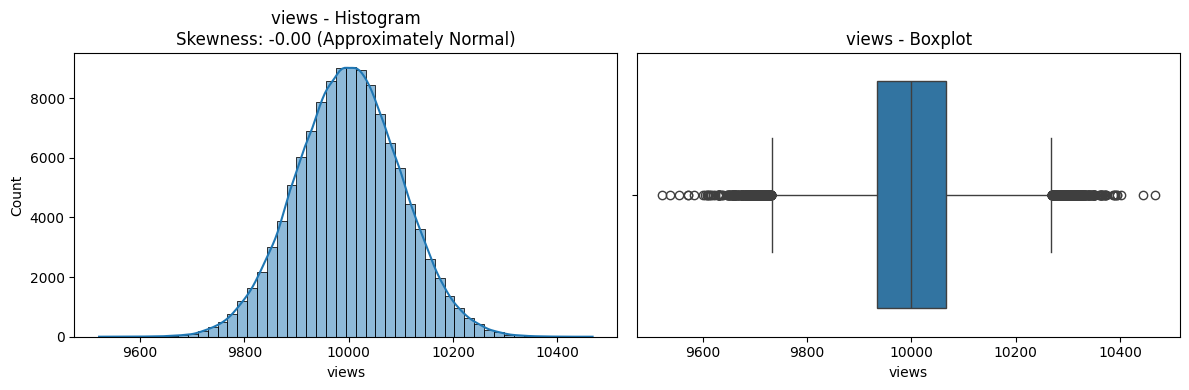

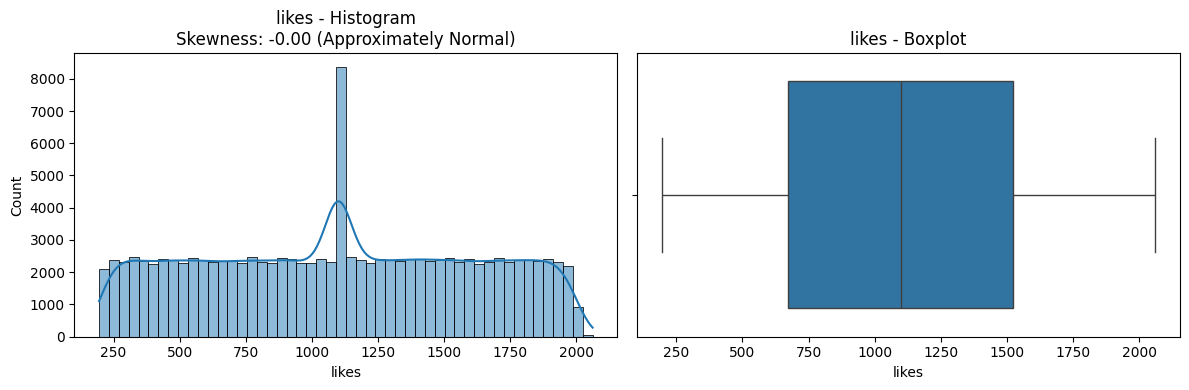

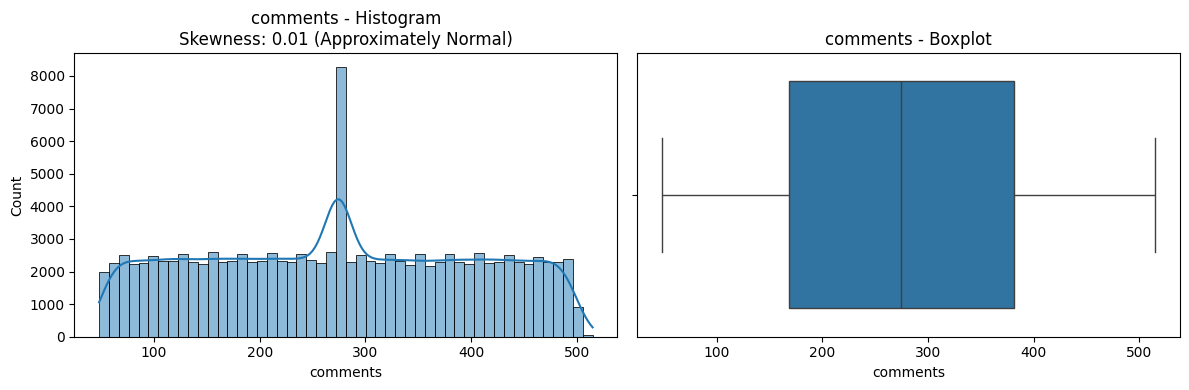

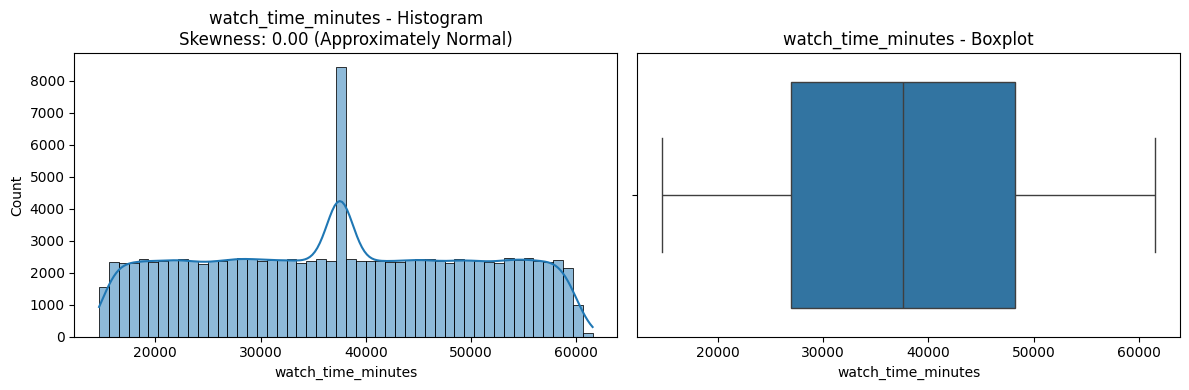

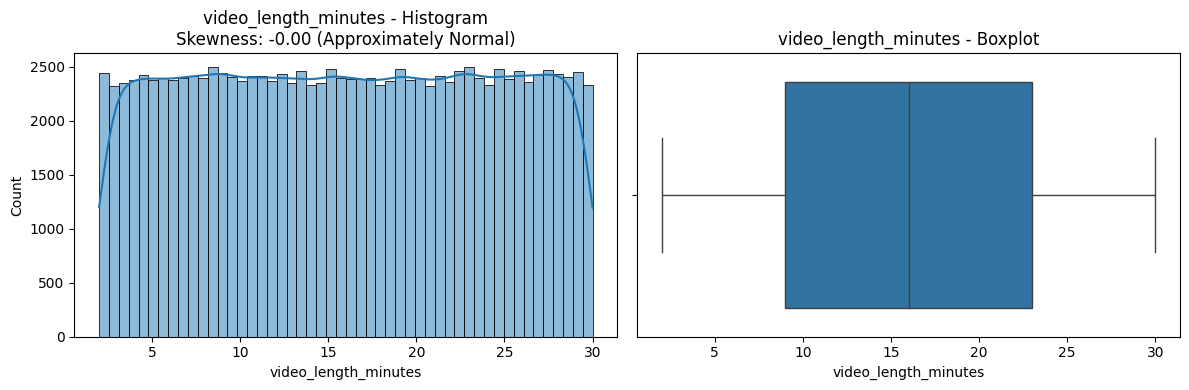

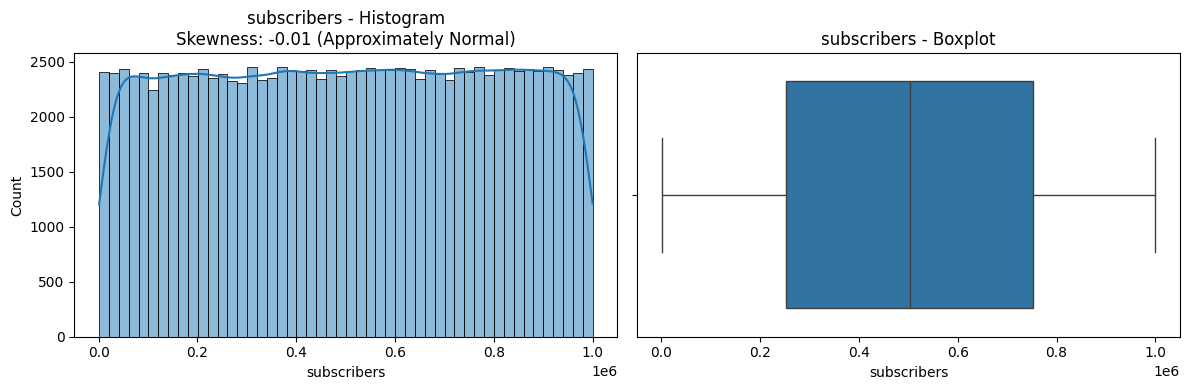

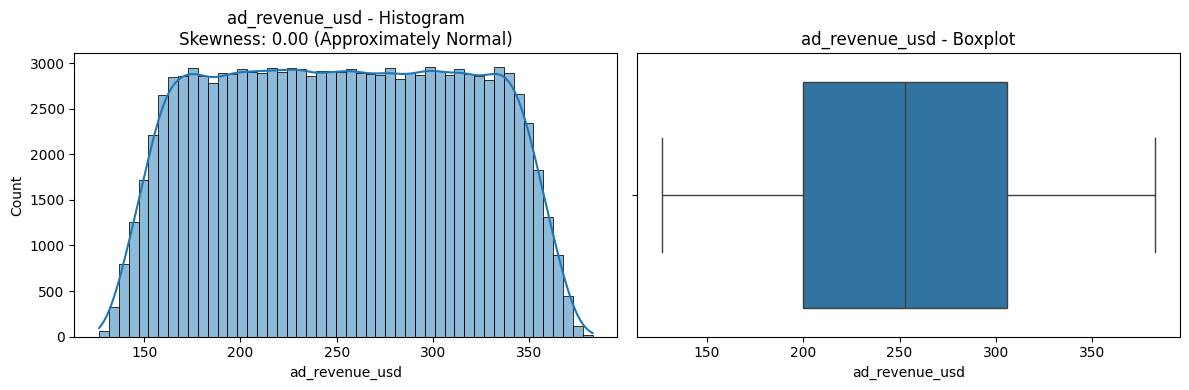

In [65]:
for col in numeric_cols:
    
    # Calculate skewness
    skew_value = df[col].skew()
    
    # Interpret skewness
    if skew_value > 1:
        skew_type = "Right Skewed (Positive)"
    elif skew_value < -1:
        skew_type = "Left Skewed (Negative)"
    else:
        skew_type = "Approximately Normal"
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Histogram\nSkewness: {skew_value:.2f} ({skew_type})")
    axes[0].set_xlabel(col)
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [66]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f" iqr method: found {len(df[(df[col] < lower) | (df[col] > upper)])} outliers in '{col}'")

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = (z_scores > 3).sum(axis=0)
for col, count in zip(numeric_cols, outliers_z):
    print(f" z-score method: found {count} outliers in '{col}'")

 iqr method: found 865 outliers in 'views'
 iqr method: found 0 outliers in 'likes'
 iqr method: found 0 outliers in 'comments'
 iqr method: found 0 outliers in 'watch_time_minutes'
 iqr method: found 0 outliers in 'video_length_minutes'
 iqr method: found 0 outliers in 'subscribers'
 iqr method: found 0 outliers in 'ad_revenue_usd'
 z-score method: found 316 outliers in 'views'
 z-score method: found 0 outliers in 'likes'
 z-score method: found 0 outliers in 'comments'
 z-score method: found 0 outliers in 'watch_time_minutes'
 z-score method: found 0 outliers in 'video_length_minutes'
 z-score method: found 0 outliers in 'subscribers'
 z-score method: found 0 outliers in 'ad_revenue_usd'


Feature Engineering

In [67]:
# Date conversion & Feature derivation

df['Date'] = pd.to_datetime(df['date'])  # Convert date column to datetime format

df['Year'] = df['Date'].dt.year       # Extract year from date

df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)     # Extract quarter from date

df['Date'] = df['Date'].dt.date  # Time-a removed 

df[['Date', 'Year', 'Quarter']].head()

,Date,Year,Quarter
0,2024-09-24,2024,2024Q3
1,2024-09-22,2024,2024Q3
2,2024-11-21,2024,2024Q4
3,2025-01-28,2025,2025Q1
4,2025-04-28,2025,2025Q2


In [68]:
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

In [69]:
df['avg_watch_time'] = df['watch_time_minutes'] / df['views']

In [70]:
# Time-based Trends (Views & Revenue)

# Group data by date and calculate total views and ad revenue
trend_df = df.groupby('Date')[['views', 'ad_revenue_usd']].sum().reset_index()

trend_df.head() 

,Date,views,ad_revenue_usd
0,2024-06-09,3371136,86792.136584
1,2024-06-10,3189709,80735.290329
2,2024-06-11,3390373,85152.787848
3,2024-06-12,3260005,82808.351046
4,2024-06-13,3228308,82065.660282


In [71]:
Q_wise_trend_df = df.groupby('Quarter')[['views', 'ad_revenue_usd']].sum().reset_index()

Q_wise_trend_df

,Quarter,views,ad_revenue_usd
0,2024Q2,73057979,1.849545e+06
1,2024Q3,302158789,7.631440e+06
2,2024Q4,302455146,7.639865e+06
3,2025Q1,297306251,7.500539e+06
4,2025Q2,225001715,5.703974e+06


In [72]:
# 1.3  Category Trend

# Group data by category and calculate average views and ad revenue
category_trend = df.groupby('category')[['views', 'ad_revenue_usd']].mean().reset_index()

category_trend


,category,views,ad_revenue_usd
0,education,9999.914078,252.564162
1,entertainment,10000.106367,252.397546
2,gaming,9999.773706,253.426887
3,lifestyle,9999.808137,251.936934
4,music,10000.379915,252.477374
5,tech,9999.009986,253.458882


In [74]:
# 1.4 Device- Trend

# Group data by device type and calculate total views
device_trend = df.groupby('device')[['views', 'ad_revenue_usd']].sum().reset_index()

device_trend

,device,views,ad_revenue_usd
0,desktop,299857961,7.564274e+06
1,mobile,299895167,7.594522e+06
2,tablet,299388105,7.574904e+06
3,tv,300838647,7.591663e+06


In [75]:
# 1.5 Country  Revenue Trends

# Group data by country and calculate total ad revenue
country_trend = (df.groupby('country')['ad_revenue_usd'].sum().reset_index().sort_values('ad_revenue_usd', ascending=False))

country_trend

,country,ad_revenue_usd
1,ca,5.106761e+06
2,de,5.095423e+06
3,in,5.089260e+06
0,au,5.026759e+06
4,uk,5.024095e+06
5,us,4.983066e+06


In [76]:
df.corr(numeric_only=True)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,Year,engagement_rate,avg_watch_time
views,1.000000,0.015198,0.018144,0.026065,0.001171,0.000750,0.037942,-0.007280,-0.007208,-0.003602
likes,0.015198,1.000000,-0.002032,0.002722,0.001771,0.003530,0.142572,-0.004800,0.969870,0.002264
comments,0.018144,-0.002032,1.000000,-0.000711,-0.002176,-0.001525,0.033633,-0.004822,0.240017,-0.001224
watch_time_minutes,0.026065,0.002722,-0.000711,1.000000,-0.000388,0.004615,0.964052,0.001815,0.001781,0.999510
video_length_minutes,0.001171,0.001771,-0.002176,-0.000388,1.000000,0.002015,0.000364,-0.005947,0.001180,-0.000404
subscribers,0.000750,0.003530,-0.001525,0.004615,0.002015,1.000000,0.005065,-0.003088,0.003035,0.004578
ad_revenue_usd,0.037942,0.142572,0.033633,0.964052,0.000364,0.005065,1.000000,0.001053,0.145553,0.963199
Year,-0.007280,-0.004800,-0.004822,0.001815,-0.005947,-0.003088,0.001053,1.000000,-0.005647,0.002037
engagement_rate,-0.007208,0.969870,0.240017,0.001781,0.001180,0.003035,0.145553,-0.005647,1.000000,0.001994
avg_watch_time,-0.003602,0.002264,-0.001224,0.999510,-0.000404,0.004578,0.963199,0.002037,0.001994,1.000000


In [77]:
# Numeric columns only
df_numeric = df.select_dtypes(include='number')

# Correlation matrix
corr = df_numeric.corr()


print(corr['ad_revenue_usd'].sort_values(ascending=False))

ad_revenue_usd          1.000000
watch_time_minutes      0.964052
avg_watch_time          0.963199
engagement_rate         0.145553
likes                   0.142572
views                   0.037942
comments                0.033633
subscribers             0.005065
Year                    0.001053
video_length_minutes    0.000364
Name: ad_revenue_usd, dtype: float64


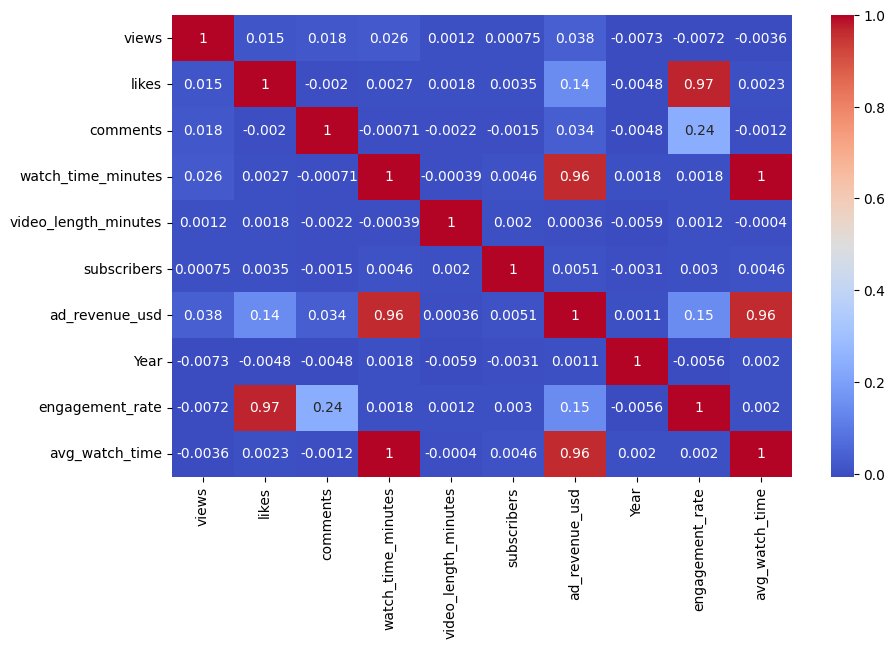

In [78]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [79]:
df = pd.get_dummies(df, columns=['category', 'device', 'country','Quarter'], drop_first=True)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   video_id                120000 non-null  object 
 1   date                    120000 non-null  object 
 2   views                   120000 non-null  int64  
 3   likes                   120000 non-null  float64
 4   comments                120000 non-null  float64
 5   watch_time_minutes      120000 non-null  float64
 6   video_length_minutes    120000 non-null  float64
 7   subscribers             120000 non-null  int64  
 8   ad_revenue_usd          120000 non-null  float64
 9   Date                    120000 non-null  object 
 10  Year                    120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  avg_watch_time          120000 non-null  float64
 13  category_entertainment  120000 non-null  bool   
 14  category_gaming         1

In [81]:
df.drop(['video_id', 'date'], axis=1, inplace=True)

In [82]:
X = df.drop(['ad_revenue_usd', 'Date'], axis=1)
y = df['ad_revenue_usd']

In [83]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
scaler = StandardScaler()
X_train = pd.DataFrame (scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame (scaler.transform(X_test), columns=X_test.columns)

In [85]:
# 1️⃣ Linear Regression


lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
# 2️⃣ Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [87]:
# 3️⃣ Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [88]:
# 4️⃣ Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [89]:
# 5️⃣ Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [90]:
# 6️⃣ Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [92]:
# Model Evaluation
# Use: R², RMSE, MAE
models = {
    'Linear Regression': lr,
    'Ridge Regression': ridge,
    'Lasso Regression': lasso,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = []          # Store all model evaluation metrics
trained_models = {}   # ✅ store trained models

for name, model in models.items():
    trained_models[name] = model  # Store the trained model
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results.append((name, r2, rmse, mae))
    print(f"{name} - R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

    

Linear Regression - R²: 0.9526, RMSE: 13.4802, MAE: 3.1185
Ridge Regression - R²: 0.9526, RMSE: 13.4801, MAE: 3.1191
Lasso Regression - R²: 0.9526, RMSE: 13.4778, MAE: 3.1224
Decision Tree - R²: 0.9010, RMSE: 19.4767, MAE: 5.3594
Random Forest - R²: 0.9500, RMSE: 13.8444, MAE: 3.5555
Gradient Boosting - R²: 0.9523, RMSE: 13.5222, MAE: 3.6239


In [93]:
results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE', 'MAE'])

results_df = results_df.sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Final Model:", best_model_name)

Final Model: Lasso Regression


In [94]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)